In [ ]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [ ]:
 #Load the  MNIST dataset
mnist = tf.keras.datasets.mnist


In [ ]:
mnist

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>

In [ ]:
# Load the training and test split of the  MNIST dataset
(training_images, training_labels), (test_images, test_labels) = mnist.load_data()
from tensorflow.keras.datasets import mnist



11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


LABEL: 5

IMAGE PIXEL ARRAY:
 [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255 247 127   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0]
 [  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82  82  56  39   0   0   0   0   0]
 [  0   0   0   0   0   0   0  18 219 253 253 253 

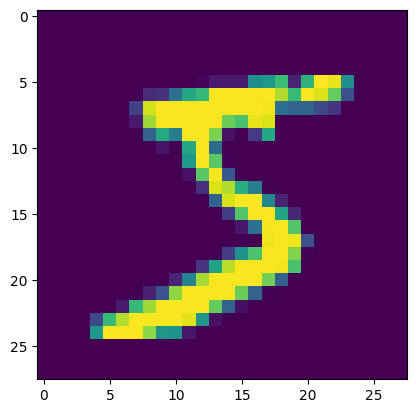

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# You can put between 0 to 59999 here
index = 0

# Set number of characters per row when printing
np.set_printoptions(linewidth=320)

# Print the label and image
print(f'LABEL: {training_labels[index]}')
print(f'\nIMAGE PIXEL ARRAY:\n {training_images[index]}')

# Visualize the image
plt.imshow(training_images[index])


In [ ]:
# Normalize the pixel values of the train and test images
training_images  = training_images / 255.0
test_images = test_images / 255.0


In [ ]:
# Build the classification model
model = tf.keras.models.Sequential([tf.keras.layers.Flatten(),
                                    tf.keras.layers.Dense(128, activation=tf.nn.relu),
                                    tf.keras.layers.Dense(10, activation=tf.nn.softmax)])


In [ ]:
# Declare sample inputs and convert to a tensor
#inputs = np.array([[0.0, 8.0, 5.0, 6.0]])
inputs = model(test_images[0:1])   # model outputs 10 logits
print("Logits:", inputs.numpy())
#inputs = tf.convert_to_tensor(inputs)
#print(f'input to softmax function: {inputs.numpy()}')


# Feed the inputs to a softmax activation function
outputs = tf.keras.activations.softmax(inputs)
np.set_printoptions(suppress=True)
print(outputs.numpy())

print(f'output of softmax function: {outputs.numpy()}')

# Get the sum of all values after the softmax
sum = tf.reduce_sum(outputs)
print(f'sum of outputs: {sum}')

# Get the index with highest value
prediction = np.argmax(outputs)
print(f'class with highest probability: {prediction}')

Logits: [[0.0918542  0.07848155 0.18371142 0.09501033 0.07584308 0.1390191  0.08477014 0.10893106 0.06270979 0.0796694 ]]
[[0.09912938 0.09781258 0.10866644 0.09944274 0.09755484 0.10391682 0.09842962 0.10083673 0.09628201 0.09792883]]
output of softmax function: [[0.09912938 0.09781258 0.10866644 0.09944274 0.09755484 0.10391682 0.09842962 0.10083673 0.09628201 0.09792883]]
sum of outputs: 0.9999999403953552
class with highest probability: 2


In [ ]:
model.compile(optimizer = tf.optimizers.Adam(),
              loss = 'sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(training_images, training_labels, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9255 - loss: 0.2637
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9655 - loss: 0.1167
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9768 - loss: 0.0794
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9816 - loss: 0.0595
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9858 - loss: 0.0457
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9886 - loss: 0.0364
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9904 - loss: 0.0298
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9929 - loss: 0.0235
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9942 - loss: 0.0191
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9953 - loss: 0.0160


In [ ]:
# Evaluate the model on unseen data
model.evaluate(test_images, test_labels)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9765 - loss: 0.0852


[0.0851672813296318, 0.9764999747276306]

In [ ]:
index =9 # choose any index from 0–9999
image = test_images[index]
label = test_labels[index]
print(test_labels[9])
print(image)


9
[[0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.      

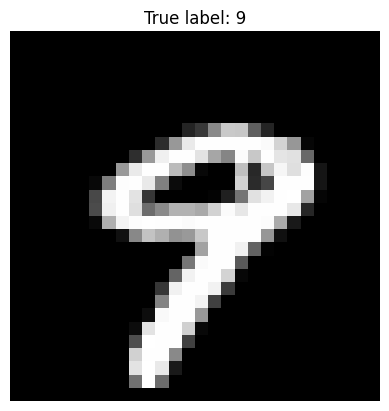

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(image, cmap='gray')
plt.title(f"True label: {label}")
plt.axis('off')
plt.show()

In [ ]:
classifications = model.predict(test_images)

print(classifications[89])



313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
[0.00000002 0.99962276 0.00000311 0.00002483 0.00001801 0.00000083 0.000023   0.000013   0.00029456 0.00000001]


In [ ]:
np.argmax(classifications[89])

np.int64(1)